## Introduction

This kernel was inspired by [this](https://www.researchgate.net/profile/G_Sundarkumar/publication/267628579_A_novel_hybrid_undersampling_method_for_mining_unbalanced_datasets_in_banking_and_insurance/links/571f482308aefa64889a1166/A-novel-hybrid-undersampling-method-for-mining-unbalanced-datasets-in-banking-and-insurance.pdf) paper. Authors of this paper described a very interesting undersampling method for imballanced datasets where first you remove outliers from majority class and then extract support vectors using OCSVM, these support vectors serves as training subset for majority class.

Also you can check my another kernels on this dataset:
* [PCA vs TSNE visualisation](https://www.kaggle.com/trolukovich/pca-vs-tsne-visualisation)
* [IsolatedForest and LOF fraud detection](https://www.kaggle.com/trolukovich/isolatedforest-and-lof-fraud-detection)

## Goal

I decided to run some experiments to test this techniqe and compare it with other techniques. Also, recently I found [this](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.QuantileTransformer.html) interesting scaler, which makes distribution of our features normal, so I decided to test it here and compare results with StandardScaler.

So, to be more specific, I want to make next things:
1. I want to create 6 datasets, on which I will train different models:

 * Unballanced dataset, sclaed with StandardScaler
 * Unballanced dataset, scaled with QuantileTransformer 
 * Ballanced with random sampling dataset, scaled with StandardScaler
 * Ballanced with random sampling dataset, scaled with QuantileTransformer
 * Ballanced with technique, described in paper dataset, scaled with StandardScaler
 * Ballanced with technique, described in paper dataset, scaled with QuantileTransformer
 
 
2. Train 3 classifiers on these datasets: SVC, RandomForest, LogisticRegression.

3. Compare results by plotting confusion matrices for each classifier.

Let's start.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.utils import shuffle
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import OneClassSVM, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

from collections import Counter

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

In [2]:
# Loading dataset
df = pd.read_csv('../input/creditcardfraud/creditcard.csv')
print(df.shape)
print(df['Class'].value_counts())
df.head()

(284807, 31)
0    284315
1       492
Name: Class, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


We have only about 0.17% fraudulent transactions in our dataset.

To ease datasets creation I'll make function that will take dataset, scale method and ballance method as input and returns train and test datasets.

The function supports 2 scaling methods:

* 'standard' - scaling, using StandardScaler
* 'quantile' - scaling, using QuantileTransformer

Also the function supports 2 ballancing techniques:

* 'random_samples' - one of the easiest and most common dataset ballancing techniques, it's just takes random samples from majority class in amount, equal to minority class.
* 'outlier_elimination' - this is my implementation of technique, described in paper, but I made some changes here: in paper, to eliminate outliers rKNN (reversal KNN) algorithm have been used, but here I'm using IsolationForest algorithm instead. Also authors of paper used all support vectors (SV) for training, but in my case if I'll use all SV, then my dataset still will be very imballanced, so I'm taking random samples from SV to create ballanced dataset.

In [3]:
def make_data(dataset, scale = None, ballance = None):
    
    '''
    Creates train and validation datasets using differend scaling and undersampling methods
    
    scale - scaling method:
     - 'standard' for StandardScaler 
     - 'quantile' for QuantileTransformer
     - None - do not use scaling
     
    ballance - method of dataset undersampling:
     - 'random_smaples' - creates subset of random non fraud_trasactions with number of samples equal to fraud transactions amount
     - 'outlier elimination' - removing outliers from majority class with IF, then extracting support vectors using OCSVM 
        and then sub-sampling this subset using random samples
     - None - do not use ballancing
    '''
    
    data = dataset.copy()
        
    # Split data to train and validation datasets
    Y = data['Class']
    X = data.drop('Class', axis = 1)
    x, val_x, y, val_y = train_test_split(X, Y, test_size = 0.15, stratify = Y, random_state = 1)
        
    # Ballancing data if method is 'random_samples'
    if ballance == 'random_samples':        
        x['Class'] = y
        fraud = x[x['Class'] == 1]        
        non_fraud = x[x['Class'] == 0]        
        non_fraud = non_fraud.sample(fraud.shape[0], random_state = 1)        
        x = pd.concat([fraud, non_fraud])
        y = x['Class']
        x = x.drop('Class', axis = 1)
    
    # Scaling data
    if scale:        
        if scale == 'standard':            
            scaler = StandardScaler()        
            x = pd.DataFrame(scaler.fit_transform(x), index = x.index, columns = x.columns)
            val_x = pd.DataFrame(scaler.transform(val_x), index = val_x.index, columns = val_x.columns)            
        elif scale == 'quantile':            
            scaler = QuantileTransformer(output_distribution = 'normal')
            x = pd.DataFrame(scaler.fit_transform(x), index = x.index, columns = x.columns)
            val_x = pd.DataFrame(scaler.transform(val_x), index = val_x.index, columns = val_x.columns)            
        else:
            raise Exception(f'{scale} is not supported scaling method.\nUse "standard" or "quantile" methods.')        
    
    # Ballancing data if method is 'outlier_elimination'
    if ballance == 'outlier_elimination':        
        x['Class'] = y
        fraud = x[x['Class'] == 1]        
        non_fraud = x[x['Class'] == 0]
        non_fraud.drop('Class', axis = 1, inplace = True)        
        
        # Detecting outliers with IF
        IF = IsolationForest(n_jobs = -1)
        outliers = IF.fit_predict(non_fraud)
                
        # Removing outliers
        non_fraud['Outliers'] = outliers
        non_fraud = non_fraud[non_fraud['Outliers'] == 1]
        non_fraud.drop('Outliers', axis = 1, inplace = True)        
        
        # Taking no more than 25000 samples for OCSVM train
        if non_fraud.shape[0] > 25000:
            non_fraud = non_fraud.sample(25000, random_state = 1)
        
        # Training OCSVM        
        ocsvm = OneClassSVM(gamma = 'auto', kernel = 'rbf', max_iter = 10)
        ocsvm.fit(non_fraud)        
        # Extracting support vectors
        vectors = pd.DataFrame(ocsvm.support_vectors_, columns = non_fraud.columns)
        
        # Ballancing dataset taking random samples from support vectors        
        non_fraud = vectors.sample(fraud.shape[0], random_state = 1)        
        non_fraud['Class'] = 0
        x = pd.concat([fraud, non_fraud])
        y = x['Class']
        x = x.drop('Class', axis = 1)
        
    elif ballance not in ['random_samples', 'outlier_elimination'] and ballance is not None:
        raise Exception(f'{ballance} is not supported balancing method.\nUse "random_samples" or "outlier_elimination" methods.')
       
    x, y = shuffle(x, y)    
       
    return (x, val_x, y, val_y)

Now it's time to create datasets and define our classifiers. I'm using default settings for all classifiers, because I'm only interested in impact of different techniques on results and do not chasing 100% accuracy.

In [4]:
# Creating datasets for experiments
datasets = {
    'Raw_standard': make_data(df, scale = 'standard'),
    'Raw_quantile': make_data(df, scale = 'quantile'),
    'Random_samples_standard': make_data(df, scale = 'standard', ballance = 'random_samples'),
    'Random_samples_quantile': make_data(df, scale = 'quantile', ballance = 'random_samples'),
    'Out_elim_standard': make_data(df, scale = 'standard', ballance = 'outlier_elimination'),
    'Out_elim_quantile': make_data(df, scale = 'quantile', ballance = 'outlier_elimination'),
           }

# Defining classifiers
classifiers = {
    'SVM': SVC(random_state = 1),
    'RandomForest': RandomForestClassifier(n_jobs = -1, random_state = 1),
    'LogisticRegression': LogisticRegression(n_jobs = -1, random_state = 1),
              }

Final part - training classifiers and plotting results.

Training SVM: Raw_standard
Training SVM: Raw_quantile
Training SVM: Random_samples_standard
Training SVM: Random_samples_quantile
Training SVM: Out_elim_standard
Training SVM: Out_elim_quantile

 SVM


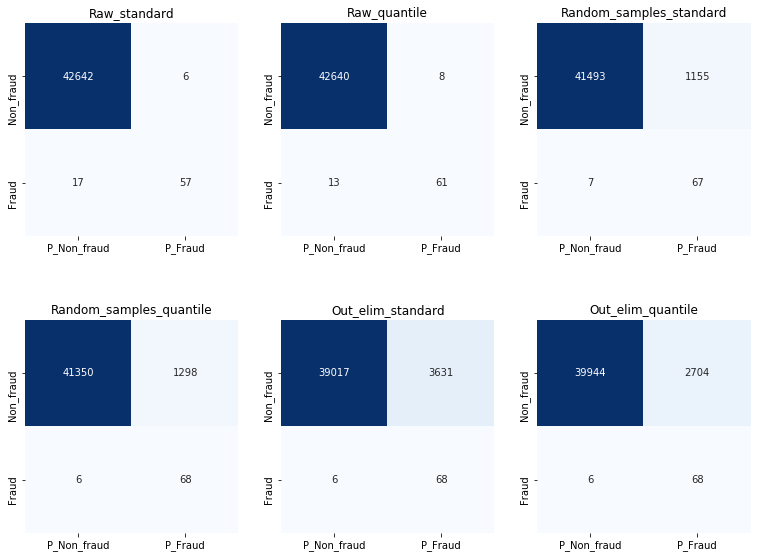

Training RandomForest: Raw_standard
Training RandomForest: Raw_quantile
Training RandomForest: Random_samples_standard
Training RandomForest: Random_samples_quantile
Training RandomForest: Out_elim_standard
Training RandomForest: Out_elim_quantile

 RandomForest


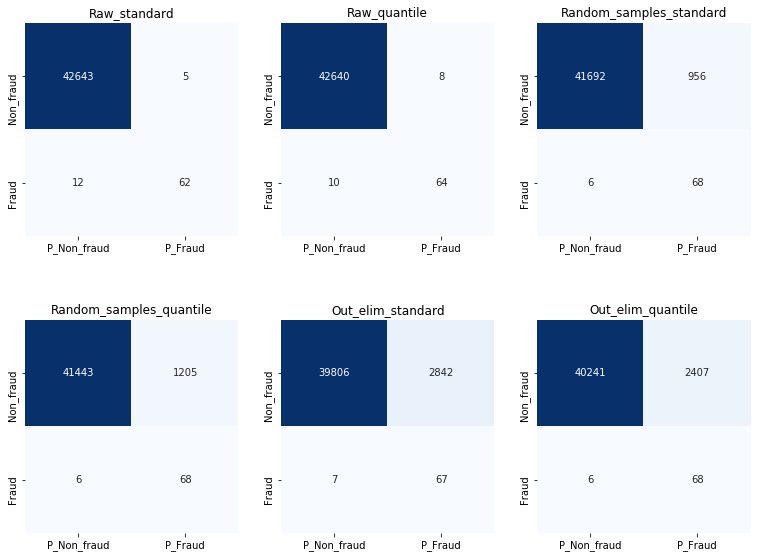

Training LogisticRegression: Raw_standard
Training LogisticRegression: Raw_quantile
Training LogisticRegression: Random_samples_standard
Training LogisticRegression: Random_samples_quantile
Training LogisticRegression: Out_elim_standard
Training LogisticRegression: Out_elim_quantile

 LogisticRegression


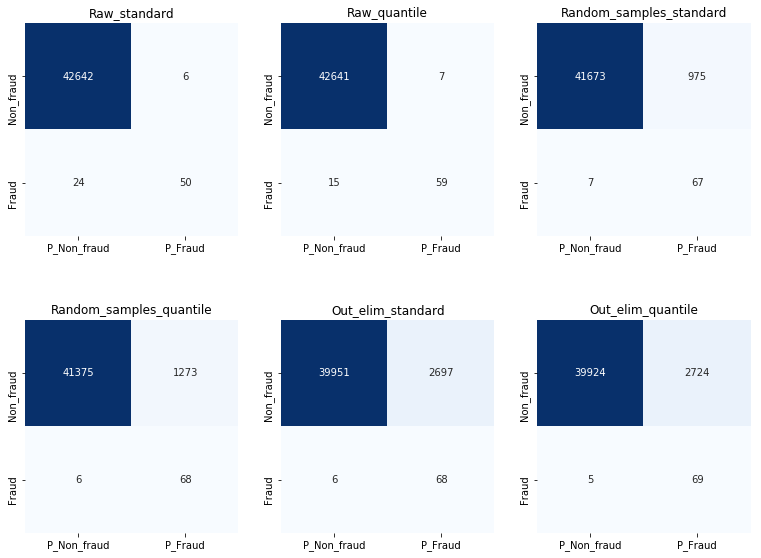

In [5]:
# Training classifiers and plotting results
for classifier in classifiers:        
    fig = plt.figure(figsize = (13, 10))
    
    for i, key in enumerate(datasets.keys()):
        print(f'Training {classifier}: {key}')
        
        # Train classifier
        clf = classifiers[classifier]
        clf.fit(datasets[key][0], datasets[key][2])
        preds = clf.predict(datasets[key][1])
        
        # Create confusin matrix plot
        plt.subplot(f'23{i+1}')
        cm = confusion_matrix(datasets[key][-1], preds)
        sns.heatmap(cm, fmt = 'd', annot = True, square = True, cbar = False, cmap = 'Blues', 
                    xticklabels =  ['P_Non_fraud', 'P_Fraud'], yticklabels = ['Non_fraud', 'Fraud']).set_title(key)
        
    print('\n', classifier)
    
    # Show plots
    plt.show()

## Conclusions:

So, in validation dataset we have 42648 non-fraudulent and 74 fraudulent transactions. By training 3 classifiers on 6 datasets we got next results:

Despite of high imballance of Raw datasets, we got relatively good results - about 67-82% fraud transactions were classified correctly, also classifiers, trained on imballanced datasets, predict non_fraud transactions with accuracy very close to 100%.

Tested undersampling techniques gave us approximately equal results in predicting fraudulent transactions (about 93%), but outlier_elimination technique gave us more false negative.